# Day 2 · Lab 2 (Part 1) — Decision Trees for CHF regression

## Purpose
This lab introduces **Decision Tree regression** using the shared CHF case study.

The goal is not to make the most accurate tree possible. The goal is to understand what a tree is doing, why an unconstrained tree can overfit, and how a pruned tree can become a useful bridge between a linear baseline and ensemble tree models.

## Learning goals
By the end of this lab, you should be able to:

- reuse the Day 1 CHF train / validation / test split;
- train a single `DecisionTreeRegressor`;
- compare shallow, deep, and pruned trees against the Day 1 Ridge baseline;
- explain `max_depth` and `min_samples_leaf` in engineering language;
- visualise the top levels of a fitted tree;
- inspect one prediction path;
- treat impurity-based feature importance as a useful but limited diagnostic.

## Expected outputs
By the end of the lab, you should have:

1. a Ridge reference result from Day 1;
2. a shallow tree result;
3. an overfitted tree demonstration;
4. a depth sweep showing underfitting and overfitting;
5. a final pruned tree;
6. a tree visualisation and a short written interpretation.

> Important: A decision tree is readable, but readability is not the same as reliability. Always check validation and test behaviour before trusting the story told by a tree.

## 1. Imports and environment check

Run this cell first. It checks the core packages needed for Day 2 Lab 2 (Part 1).

In [59]:
from pathlib import Path
import sys
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

print("Python executable :", sys.executable)
print("Python version    :", platform.python_version())
print("Platform          :", platform.platform())
print("\nCore imports succeeded.")

Python executable : /opt/homebrew/Caskroom/miniforge/base/envs/ai4nth/bin/python
Python version    : 3.11.15
Platform          : macOS-26.5.1-arm64-arm-64bit

Core imports succeeded.


## 2. Locate the notebook and data folders

This notebook is assumed to live in:

`ai4nth-summer-school/course_materials/day2_tree_models/notebooks/`

and the case-study CSV files are assumed to be in:

`ai4nth-summer-school/datasets`

So, relative to this notebook, the data folder should be found at:

`../../../datasets`

In [60]:
notebook_dir = Path.cwd().resolve()
bundle_root = notebook_dir.parents[2]
data_dir = bundle_root / "datasets"

print("Notebook directory :", notebook_dir)
print("Bundle root        :", bundle_root)
print("Dataset directory  :", data_dir)

assert data_dir.exists(), f"Dataset directory not found: {data_dir}"
print("\nPASS: dataset directory exists.")

Notebook directory : /Users/junwenyin/Library/CloudStorage/OneDrive-ScienceandTechnologyFacilitiesCouncil/5-lectures/CCP-NTH AI summer school/ai4nth-summer-school/course_materials/day2_tree_models/notebooks
Bundle root        : /Users/junwenyin/Library/CloudStorage/OneDrive-ScienceandTechnologyFacilitiesCouncil/5-lectures/CCP-NTH AI summer school/ai4nth-summer-school
Dataset directory  : /Users/junwenyin/Library/CloudStorage/OneDrive-ScienceandTechnologyFacilitiesCouncil/5-lectures/CCP-NTH AI summer school/ai4nth-summer-school/datasets

PASS: dataset directory exists.


## 3. Load the train / validation / test data

Let's use the organiser-provided split. Do not reshuffle rows for the main comparison.

In [61]:
# =========================
# EDIT THESE FILENAMES ONLY IF YOUR DATA FOLDER IS DIFFERENT
# =========================

train_file = "chf_train.csv"
val_file = "chf_val.csv"
test_file = "chf_test.csv"

ood_files = [
    "chf_OOD_Kim2000.csv",
    "chf_OOD_Lee1966.csv",
    "chf_OOD_Peterlongo1966.csv",
]

target_col = "CHF (kW/m^2)"
id_col = "Number"
reference_col = "Reference name"


def load_csv(data_dir: Path, filename: str) -> pd.DataFrame:
    path = data_dir / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)


train_df = load_csv(data_dir, train_file)
val_df = load_csv(data_dir, val_file)
test_df = load_csv(data_dir, test_file)

print(f"Train shape: {train_df.shape}")
print(f"Val shape  : {val_df.shape}")
print(f"Test shape : {test_df.shape}")

Train shape: (10424, 11)
Val shape  : (3150, 11)
Test shape : (2307, 11)


## 4. Quick inspection of the data

Before modelling, confirm the target, features, sources, and missing values.

In [62]:
assert target_col in train_df.columns, f"Target column '{target_col}' not found in training data."

print("Columns in the dataset:")
for c in train_df.columns:
    print("-", c)

print("\nTraining data preview:")
display(train_df.head())

print("\nRows by reference:")
display(train_df[reference_col].value_counts().to_frame("train rows").head(12))

print("\nMissing values by split:")
missing_summary = pd.DataFrame({
    "train_missing": train_df.isna().sum(),
    "val_missing": val_df.isna().sum(),
    "test_missing": test_df.isna().sum(),
})
display(missing_summary)

Columns in the dataset:
- Number
- Reference ID
- Tube Diameter (m)
- Heated Length (m)
- Pressure (kPa)
- Mass Flux (kg/m^2/s)
- Outlet Quality
- Inlet Subcooling (kJ/kg)
- Inlet Temperature (degreeC )
- CHF (kW/m^2)
- Reference name

Training data preview:


,Number,Reference ID,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC ),CHF (kW/m^2),Reference name
0,1650,9,0.00999,0.6,2991.0,220.0,0.751,839.0,39.61,2002.0,"Becker 1963 AE 114, 1965 AE-177"
1,1651,9,0.00999,0.6,2305.0,225.0,0.737,776.0,39.16,2009.0,"Becker 1963 AE 114, 1965 AE-177"
2,1652,9,0.00999,0.6,2599.0,221.0,0.750,812.0,37.54,2009.0,"Becker 1963 AE 114, 1965 AE-177"
3,1653,9,0.00999,0.6,2040.0,228.0,0.725,749.0,38.75,2006.0,"Becker 1963 AE 114, 1965 AE-177"
4,1654,9,0.00999,0.6,1775.0,228.0,0.726,717.0,38.86,1998.0,"Becker 1963 AE 114, 1965 AE-177"



Rows by reference:


,train rows
Reference name,
Zenkevich,5252
Smolin 1979,2928
Becker et al 1971,1435
"Becker 1963 AE 114, 1965 AE-177",809



Missing values by split:


,train_missing,val_missing,test_missing
Number,0,0,0
Reference ID,0,0,0
Tube Diameter (m),0,0,0
Heated Length (m),0,0,0
Pressure (kPa),0,0,0
Mass Flux (kg/m^2/s),0,0,0
Outlet Quality,0,0,0
Inlet Subcooling (kJ/kg),0,0,0
Inlet Temperature (degreeC ),0,0,0
CHF (kW/m^2),0,0,0


## 5. Define features and target

We start with the same three input variables used in Day 1 so that the model comparison is direct. The optional extension switches to all physical input variables.

In [63]:
day1_feature_cols = [
    "Pressure (kPa)",
    "Mass Flux (kg/m^2/s)",
    "Outlet Quality",
]

all_physical_feature_cols = [
    "Tube Diameter (m)",
    "Heated Length (m)",
    "Pressure (kPa)",
    "Mass Flux (kg/m^2/s)",
    "Outlet Quality",
    "Inlet Subcooling (kJ/kg)",
    "Inlet Temperature (degreeC )",
]

## 6. Helper functions

These helpers keep **metrics** and **preprocessing** consistent across every model, so that differences in the tables below come from the *model*, not from how we measured it.

### The three regression metrics we report
Every result table shows the same three numbers. Read them **together**:

- **MAE (Mean Absolute Error)** — the average size of the error, in the same units as CHF (kW/m²): *"on average we are off by this much."* Not overly sensitive to a few large misses.
- **RMSE (Root Mean Squared Error)** — also in kW/m², but squaring **punishes large errors more heavily**. RMSE is always ≥ MAE; a big gap between them means a few predictions are badly wrong.
- **R² (coefficient of determination)** — unitless, ≤ 1. It answers *"how much better than always guessing the mean?"* **1.0** = perfect, **0** = no better than the mean, **negative** = *worse* than the mean. On the out-of-domain data at the end of the lab you will see R² go negative — that is the model genuinely failing.

> Rule of thumb: compare models on **RMSE** (it is the score we optimise), and watch **R²** as a sanity check, especially out-of-domain.

### The preprocessing helper
`make_preprocessor` fills missing values (median for numeric columns, most-frequent for categorical) and *optionally* standardises the numeric columns. We only scale for the **linear** Ridge model: scaling matters for linear/penalised models, but a decision tree is **scale-invariant** — it only asks *"is this feature above a threshold?"*, so multiplying a column by 1000 changes nothing. That is why trees are trained with `scale_numeric=False`.


In [64]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def make_preprocessor(X, scale_numeric: bool = False):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    transformers = [("num", Pipeline(steps=numeric_steps), numeric_cols)]

    if categorical_cols:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ])
        transformers.append(("cat", categorical_transformer, categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")


def evaluate_on_splits(model_name, model, include_train=False):
    split_data = []
    if include_train:
        split_data.append(("Train", X_train, y_train))
    split_data.extend([
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ])

    rows = []
    predictions = {}
    for split_name, X, y in split_data:
        pred = model.predict(X)
        row = regression_metrics(y, pred)
        row["Model"] = model_name
        row["Split"] = split_name
        rows.append(row)
        predictions[split_name] = pred

    return pd.DataFrame(rows), predictions


def display_metric_table(results_df):
    ordered = results_df[["Model", "Split", "MAE", "RMSE", "R2"]].copy()
    display(ordered.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}"}))

## 7. Reproduce the Day 1 Ridge baseline

Before reaching for a nonlinear tree, we re-establish a **simple reference model**: Ridge regression (a linear model with a small penalty on large coefficients). A more complex model is only worth its extra complexity if it can beat this baseline — always keep a simple yardstick.

Notes for reading the two cells below:

- The **first cell** uses the **three Day-1 features** (`use_all_physical_features = False`) so the tree-vs-Ridge comparison is like-for-like with yesterday.
- The **second cell** is the optional **extension**: it switches to all physical inputs. ⚠️ It rebuilds `X_train` / `X_val` / `X_test`, so **whichever of these two cells you run last decides the feature set used by every model further down the notebook.** For the main story, run the first cell and skip the second.
- We pass `scale_numeric=True` for Ridge (linear models care about scale). `include_train=True` also reports the **training** score next to validation/test — comparing *train vs validation* is how we will diagnose over- and under-fitting throughout this lab.


In [65]:
# Start with the Day 1 features so the comparison is direct.
# Change this to True during the extension if you want to use all physical inputs.
use_all_physical_features = False
# use_all_physical_features = True

feature_cols = all_physical_feature_cols if use_all_physical_features else day1_feature_cols

print("Selected feature columns:")
for c in feature_cols:
    print("-", c)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

ridge_model = Pipeline(steps=[
    ("preprocess", make_preprocessor(X_train, scale_numeric=True)),
    ("model", Ridge(alpha=1.0)),
])

ridge_model.fit(X_train, y_train)
ridge_results, ridge_predictions = evaluate_on_splits("Ridge", ridge_model, include_train=True)

display_metric_table(ridge_results)

Selected feature columns:
- Pressure (kPa)
- Mass Flux (kg/m^2/s)
- Outlet Quality

Shapes:
X_train: (10424, 3) y_train: (10424,)
X_val  : (3150, 3) y_val  : (3150,)
X_test : (2307, 3) y_test : (2307,)


,Model,Split,MAE,RMSE,R2
0,Ridge,Train,587.69,782.60,0.655
1,Ridge,Validation,579.24,743.54,0.570
2,Ridge,Test,654.63,819.71,-0.003


In [66]:
# Change Day 1 features to all_physical_features during this cell if you want to use all physical inputs.
# use_all_physical_features = False
use_all_physical_features = True

feature_cols = all_physical_feature_cols if use_all_physical_features else day1_feature_cols

print("Selected feature columns:")
for c in feature_cols:
    print("-", c)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

ridge_model = Pipeline(steps=[
    ("preprocess", make_preprocessor(X_train, scale_numeric=True)),
    ("model", Ridge(alpha=1.0)),
])

ridge_model.fit(X_train, y_train)
ridge_results, ridge_predictions = evaluate_on_splits("Ridge", ridge_model, include_train=True)

display_metric_table(ridge_results)

Selected feature columns:
- Tube Diameter (m)
- Heated Length (m)
- Pressure (kPa)
- Mass Flux (kg/m^2/s)
- Outlet Quality
- Inlet Subcooling (kJ/kg)
- Inlet Temperature (degreeC )

Shapes:
X_train: (10424, 7) y_train: (10424,)
X_val  : (3150, 7) y_val  : (3150,)
X_test : (2307, 7) y_test : (2307,)


,Model,Split,MAE,RMSE,R2
0,Ridge,Train,475.29,662.74,0.753
1,Ridge,Validation,460.11,590.42,0.729
2,Ridge,Test,486.70,609.24,0.446


## 8. Train a shallow Decision Tree

### What a regression tree actually does
A decision tree splits the data with a sequence of yes/no questions of the form *"is this feature ≤ some threshold?"*. Each split cuts the data into two groups, and the tree keeps splitting until a group becomes a **leaf**. The prediction for any new sample is simply the **mean CHF of the training rows that fell into the same leaf**. In other words, a tree carves the input space into boxes and predicts a **constant** inside each box (we draw this literally in Section 10b).

This is why a tree needs no feature scaling, handles nonlinearity naturally, and is easy to read — but also why it can only ever produce a *staircase*, never a smooth curve.

### The two knobs we use to control it
Both limit how finely the tree may cut the data, i.e. its **complexity**:

- **`max_depth`** — the maximum number of questions asked in a row before a prediction. Depth 3 means at most 3 nested questions → at most 8 leaves. Small depth = coarse and readable, but risks **underfitting**.
- **`min_samples_leaf`** — the minimum number of training rows allowed in a leaf. Large values (here **80**) forbid tiny leaves built from a handful of points, which is our main defence against **overfitting**.

A shallow tree is deliberately simple. **What to look for below:** its training and validation errors should be fairly *close to each other* but both only mediocre — the tell-tale sign of a model that is a little too simple (**underfitting**).


In [67]:
shallow_tree = Pipeline(steps=[
    ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
    ("model", DecisionTreeRegressor(
        max_depth=3,
        min_samples_leaf=80,
        random_state=42,
    )),
])

shallow_tree.fit(X_train, y_train)
shallow_results, shallow_predictions = evaluate_on_splits(
    "Shallow tree", shallow_tree, include_train=True
)

display_metric_table(shallow_results)

,Model,Split,MAE,RMSE,R2
0,Shallow tree,Train,508.72,701.95,0.722
1,Shallow tree,Validation,518.87,713.14,0.604
2,Shallow tree,Test,419.40,547.08,0.553


## 9. Demonstrate overfitting with an unconstrained tree

Now we remove the guardrails: `max_depth=None` and `min_samples_leaf=1` let the tree grow until almost every training row sits in its own leaf. The tree can then effectively **memorise** the training set.

**The signature of overfitting is a gap.** In the three-row table below (Ridge, shallow tree, unconstrained tree), focus on the unconstrained tree:

- its **Train** RMSE will be very low (near-perfect memory of the training rows), but
- its **Validation / Test** RMSE will be clearly worse.

A model that is excellent on data it has already seen but mediocre on data it has not is not learning the physics — it is learning the noise. The shallow tree above, and the pruned tree we build next, both deliberately trade a little training accuracy for a **smaller train-vs-test gap**, which is what actually matters in deployment.


In [68]:
deep_tree = Pipeline(steps=[
    ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
    ("model", DecisionTreeRegressor(
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
    )),
])

deep_tree.fit(X_train, y_train)
deep_results, deep_predictions = evaluate_on_splits(
    "Unconstrained tree", deep_tree, include_train=True
)

tree_overfit_comparison = pd.concat(
    [ridge_results, shallow_results, deep_results],
    ignore_index=True,
)
display_metric_table(tree_overfit_comparison)

,Model,Split,MAE,RMSE,R2
0,Ridge,Train,475.29,662.74,0.753
1,Ridge,Validation,460.11,590.42,0.729
2,Ridge,Test,486.70,609.24,0.446
3,Shallow tree,Train,508.72,701.95,0.722
4,Shallow tree,Validation,518.87,713.14,0.604
5,Shallow tree,Test,419.40,547.08,0.553
6,Unconstrained tree,Train,0.00,0.00,1.000
7,Unconstrained tree,Validation,267.64,414.89,0.866
8,Unconstrained tree,Test,113.08,211.53,0.933


## 10. Sweep tree depth

`max_depth` controls how many sequential questions the tree can ask. Rather than guessing a single value, we now train a tree at **every depth from 1 to 16** and plot the error, letting the data show us the right complexity.

**How to read the curve you are about to produce** — this is one of the most important plots in the lab:

- **Train RMSE** falls steadily as depth grows: a deeper tree can always fit its *own* training data better.
- **Validation / Test RMSE** falls at first (the tree is learning real structure), then **flattens or rises** (the tree starts chasing noise). This U-shape is the **bias–variance trade-off** made visible.
- The **best depth is where the validation curve bottoms out** — *not* where the training curve is lowest. The widening gap between the train and validation curves to the right of that minimum is exactly the overfitting we forced in Section 9.


,MAE,RMSE,R2,max_depth,Split
0,752.376052,997.254656,0.439893,1,Train
1,771.900058,994.949718,0.230046,1,Validation
2,662.019588,814.275441,0.009927,1,Test
3,615.285367,839.782933,0.602815,2,Train
4,651.097474,878.697365,0.399461,2,Validation


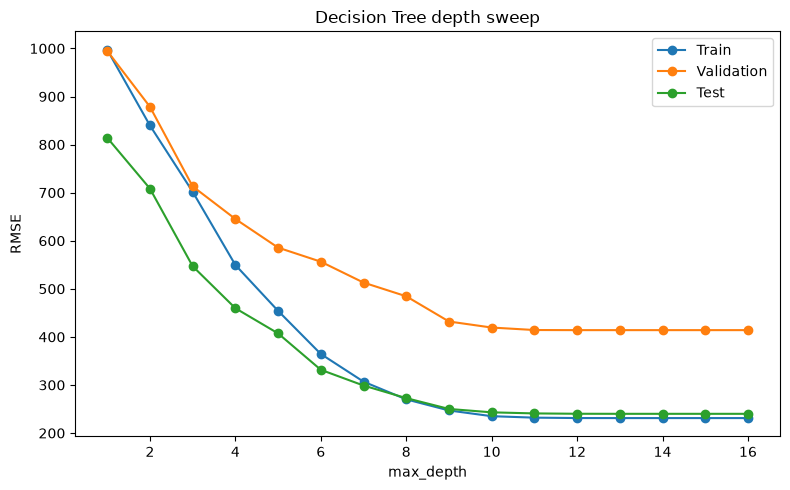

,MAE,RMSE,R2,max_depth,Split
34,277.98,414.08,0.867,12,Validation


In [69]:
depth_rows = []

for depth in range(1, 17):
    model = Pipeline(steps=[
        ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
        ("model", DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=20,
            random_state=42,
        )),
    ])
    model.fit(X_train, y_train)

    for split_name, X, y in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred = model.predict(X)
        row = regression_metrics(y, pred)
        row["max_depth"] = depth
        row["Split"] = split_name
        depth_rows.append(row)

depth_results = pd.DataFrame(depth_rows)
display(depth_results.head())

plt.figure(figsize=(8, 5))
for split_name in ["Train", "Validation", "Test"]:
    subset = depth_results[depth_results["Split"] == split_name]
    plt.plot(subset["max_depth"], subset["RMSE"], marker="o", label=split_name)

plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Decision Tree depth sweep")
plt.legend()
plt.tight_layout()
plt.show()

best_depth_row = (
    depth_results[depth_results["Split"] == "Validation"]
    .sort_values("RMSE")
    .head(1)
)
display(best_depth_row.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.3f}"}))

## 10b. What is the tree actually doing? A one-feature view

The depth sweep told us *how well* trees of different depths score, but not *what* a tree does.

The clearest way to see this is to fit a tree on a **single feature** and plot its prediction as a curve. A regression tree can only output a **piecewise-constant staircase**: each leaf is one flat step. This single picture explains three things at once:

- why trees capture nonlinear shape (many steps approximate a curve);
- why a deep tree overfits (too many tiny steps chase noise);
- why trees **cannot extrapolate** a trend beyond the training range (the outermost step just continues flat) — the point we return to in Section 17.

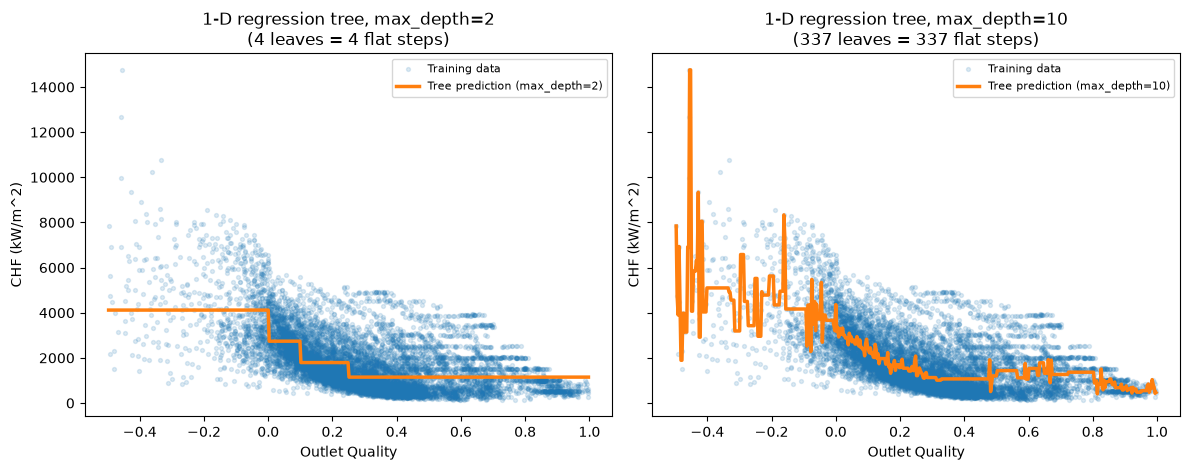

Notice:
- The prediction is a staircase of flat steps, never a smooth line.
- A deeper tree simply uses more, narrower steps.
- Outside the training range the last step is extended flat: trees cannot extrapolate a trend.


In [70]:
# Fit a tree on a SINGLE feature so we can draw its prediction as a 1-D curve.
# Outlet Quality is a good choice because it has a strong, physically meaningful
# relationship with CHF.
single_feature = "Outlet Quality"
q_train = X_train[[single_feature]].to_numpy()

# A dense grid across the observed range, used to draw the prediction curve.
q_grid = np.linspace(q_train.min(), q_train.max(), 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

for ax, depth in zip(axes, [2, 10]):
    tree_1d = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree_1d.fit(q_train, y_train)

    ax.scatter(q_train, y_train, s=8, alpha=0.15, label="Training data")
    ax.plot(q_grid, tree_1d.predict(q_grid), color="C1", linewidth=2.5,
            label=f"Tree prediction (max_depth={depth})")
    ax.set_xlabel(single_feature)
    ax.set_ylabel("CHF (kW/m^2)")
    ax.set_title(f"1-D regression tree, max_depth={depth}\n"
                 f"({tree_1d.get_n_leaves()} leaves = {tree_1d.get_n_leaves()} flat steps)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print("Notice:")
print("- The prediction is a staircase of flat steps, never a smooth line.")
print("- A deeper tree simply uses more, narrower steps.")
print("- Outside the training range the last step is extended flat: trees cannot extrapolate a trend.")

## 11. Tune tree hyperparameters with cross-validation

The depth sweep changed one parameter at a time. Realistic model selection searches several pruning parameters **together**, and it needs a more stable score than a single validation split can provide.

### What k-fold cross-validation does
`GridSearchCV` with `KFold(n_splits=5)` splits the **training set** into 5 equal folds. For each combination of hyperparameters it trains on 4 folds and scores on the held-out 5th, rotating through all 5 folds and averaging the scores. So every candidate tree is judged on 5 different held-out slices instead of one lucky (or unlucky) split — a far more trustworthy estimate of how it will generalise.

Crucially, we run this on the **training set only**. The validation and test sets stay untouched, so they remain *honest external checks* after the search has already chosen a winner. (Peeking at the test set during tuning is the most common way to fool yourself in ML.)


In [71]:
tree_for_search = Pipeline(steps=[
    ("preprocess", make_preprocessor(X_train, scale_numeric=False)),
    ("model", DecisionTreeRegressor(random_state=42)),
])

# We deliberately restrict the search to pruning-friendly ranges.
# max_depth is capped (no unconstrained None) and leaves are kept reasonably
# large, so the "best" tree is a genuinely pruned tree rather than the deep
# memorising tree from Section 9. This keeps the model-selection story honest:
# the aim is a readable, generalisable tree, not the lowest possible training error.
param_grid = {
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_samples_leaf": [10, 20, 30, 50],
    "model__min_samples_split": [10, 30, 60],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_search = GridSearchCV(
    estimator=tree_for_search,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
cv_search.fit(X_train, y_train)

print("Best CV RMSE:", -cv_search.best_score_)
print("Best parameters:")
for name, value in cv_search.best_params_.items():
    print(f"- {name}: {value}")

cv_results = pd.DataFrame(cv_search.cv_results_)
cv_summary = cv_results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "param_model__min_samples_split",
]].copy()

cv_summary["CV RMSE"] = -cv_summary["mean_test_score"]
cv_summary["Train CV RMSE"] = -cv_summary["mean_train_score"]
cv_summary = cv_summary.sort_values("rank_test_score")

display(cv_summary[[
    "rank_test_score",
    "CV RMSE",
    "std_test_score",
    "Train CV RMSE",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "param_model__min_samples_split",
]].head(10).style.format({
    "CV RMSE": "{:.2f}",
    "std_test_score": "{:.2f}",
    "Train CV RMSE": "{:.2f}",
}))

Best CV RMSE: 252.88014997232168
Best parameters:
- model__max_depth: 10
- model__min_samples_leaf: 10
- model__min_samples_split: 10


,rank_test_score,CV RMSE,std_test_score,Train CV RMSE,param_model__max_depth,param_model__min_samples_leaf,param_model__min_samples_split
60,1,252.88,19.39,203.62,10,10,10
61,2,265.35,19.91,217.78,10,10,30
63,3,288.13,18.37,251.23,10,20,10
64,3,288.13,18.37,251.23,10,20,30
48,5,288.63,15.56,250.82,8,10,10
49,6,295.12,16.20,257.84,8,10,30
62,7,310.14,23.74,266.47,10,10,60
51,8,310.76,14.63,278.68,8,20,10
52,8,310.76,14.63,278.68,8,20,30
65,10,313.88,17.35,277.82,10,20,60


## 12. Train the final CV-selected pruned tree

The final tree uses the hyperparameters selected by cross-validation on the training set only.

Two cautions worth stating explicitly to the class:

- **CV chooses on an internal score.** The grid was capped at moderate depths, so the selected tree is genuinely pruned. But cross-validation optimises an *internal* training-fold RMSE. It does **not** guarantee the best external behaviour, so we still re-check on the untouched validation and test sets below.
- **Lowest depth is rarely the goal.** Compare the `CV RMSE` and `Train CV RMSE` columns above: as depth grows, the training score keeps improving while the cross-validated score flattens or worsens. That gap *is* overfitting, and it is why we did not simply pick the deepest tree.

In [72]:
final_tree = cv_search.best_estimator_

final_tree_results, final_tree_predictions = evaluate_on_splits(
    "CV-selected pruned tree", final_tree, include_train=True
)

tree_comparison = pd.concat(
    [ridge_results, shallow_results, deep_results, final_tree_results],
    ignore_index=True,
)

display_metric_table(tree_comparison)


,Model,Split,MAE,RMSE,R2
0,Ridge,Train,475.29,662.74,0.753
1,Ridge,Validation,460.11,590.42,0.729
2,Ridge,Test,486.70,609.24,0.446
3,Shallow tree,Train,508.72,701.95,0.722
4,Shallow tree,Validation,518.87,713.14,0.604
5,Shallow tree,Test,419.40,547.08,0.553
6,Unconstrained tree,Train,0.00,0.00,1.000
7,Unconstrained tree,Validation,267.64,414.89,0.866
8,Unconstrained tree,Test,113.08,211.53,0.933
9,CV-selected pruned tree,Train,120.77,192.88,0.979


## 13. Visualise the top levels of the final tree

Read the first few splits as engineering questions about pressure, mass flux, and quality.

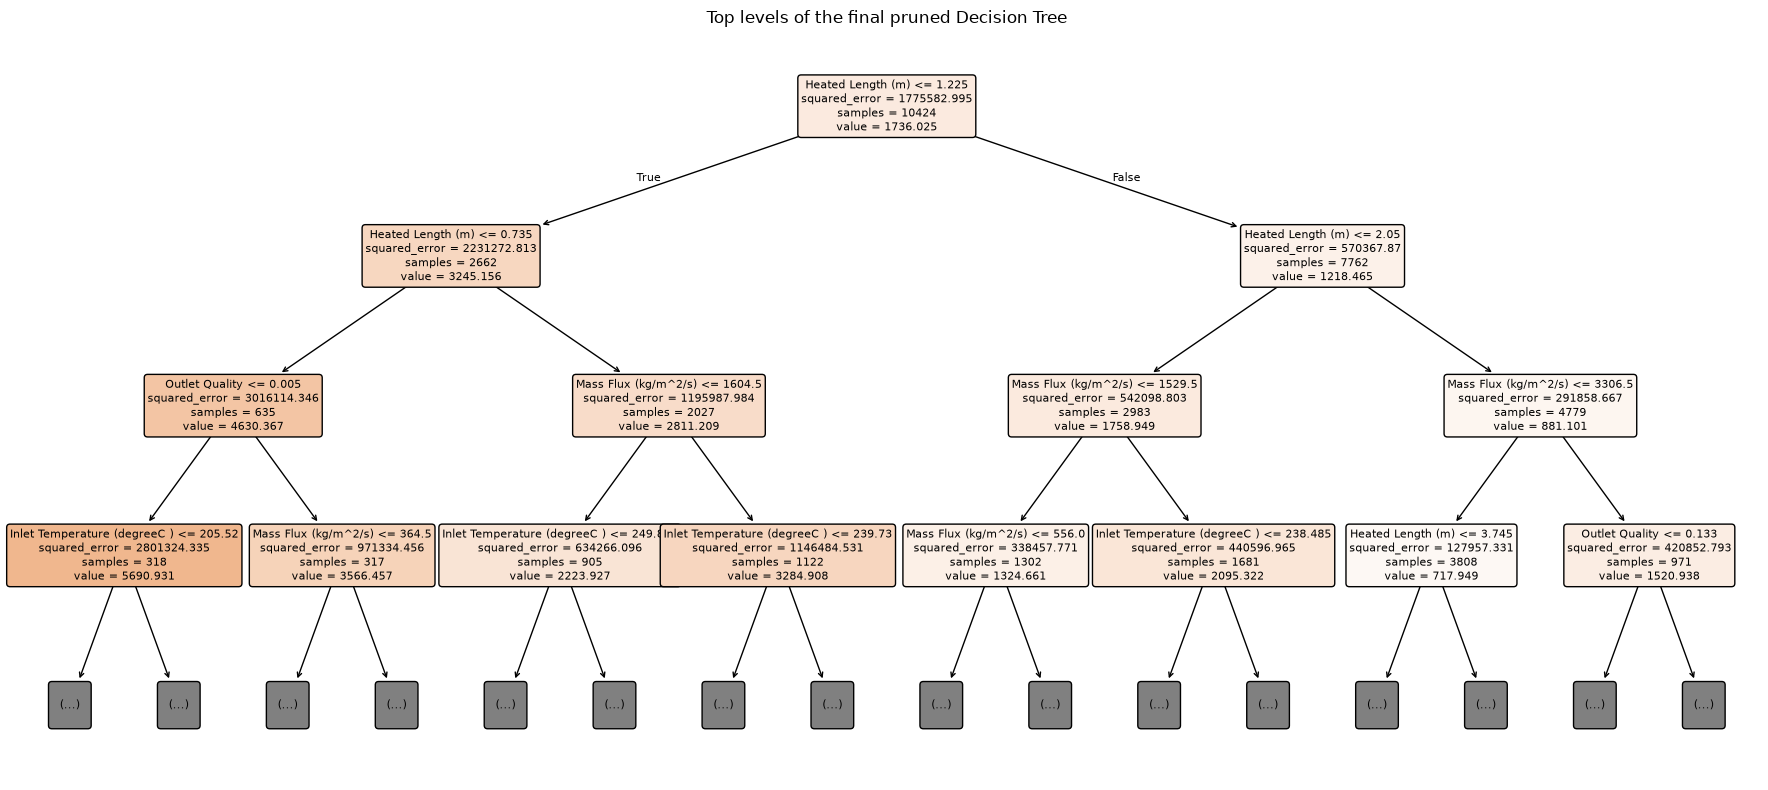

In [73]:
fitted_tree = final_tree.named_steps["model"]

plt.figure(figsize=(18, 8))
plot_tree(
    fitted_tree,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Top levels of the final pruned Decision Tree")
plt.tight_layout()
plt.show()

### How to read each box

For a **regression** tree, every box shows four lines (the labels differ from a classification tree):

- **`Outlet Quality <= 0.247`** — the split question. Samples that satisfy it go *left*, the rest go *right*.
- **`squared_error = ...`** — the impurity of the node: the mean squared error of the CHF values that land here. Lower means the CHF values in this node are more similar, i.e. a "purer" node. (A classification tree would show `gini` or `entropy` instead.)
- **`samples = ...`** — how many training rows reached this node.
- **`value = ...`** — the node's prediction: the **mean CHF** of its training rows. For a leaf, this number is exactly what the tree returns.

Colour intensity encodes `value`: darker boxes predict higher CHF. Reading the first two or three splits top-down is the honest way to describe "what the tree learned" — but remember it describes *this fitted tree on this split*, not a physical law.

## 14. Inspect one prediction path

The path shows which split decisions were used for one test sample. This is useful for explanation, but remember it describes this fitted tree, not a universal physical law.

In [74]:
sample_index = 0
sample = X_test.iloc[[sample_index]]
observed = y_test.iloc[sample_index]
predicted = final_tree.predict(sample)[0]

preprocessed_sample = final_tree.named_steps["preprocess"].transform(sample)
node_indicator = fitted_tree.decision_path(preprocessed_sample)
leaf_id = fitted_tree.apply(preprocessed_sample)[0]

print("Sample ID :", test_df.iloc[sample_index][id_col])
print("Observed  :", observed)
print("Predicted :", predicted)
print("Leaf node :", leaf_id)
print("\nInput features:")
display(sample)

tree_ = fitted_tree.tree_
node_index = node_indicator.indices[
    node_indicator.indptr[0] : node_indicator.indptr[1]
]

print("\nDecision path:")
for node_id in node_index:
    if leaf_id == node_id:
        print(f"node {node_id}: leaf prediction = {tree_.value[node_id][0, 0]:.2f}")
        continue

    feature_id = tree_.feature[node_id]
    threshold = tree_.threshold[node_id]
    feature_name = feature_cols[feature_id]
    feature_value = preprocessed_sample[0, feature_id]
    direction = "<=" if feature_value <= threshold else ">"
    print(
        f"node {node_id}: {feature_name} = {feature_value:.3f} "
        f"{direction} {threshold:.3f}"
    )

Sample ID : 3387
Observed  : 2095.0
Predicted : 2223.6
Leaf node : 129

Input features:


,Tube Diameter (m),Heated Length (m),Pressure (kPa),Mass Flux (kg/m^2/s),Outlet Quality,Inlet Subcooling (kJ/kg),Inlet Temperature (degreeC )
0,0.01,1.0,9800.0,570.0,0.421,923.0,111.88



Decision path:
node 0: Heated Length (m) = 1.000 <= 1.225
node 1: Heated Length (m) = 1.000 > 0.735
node 99: Mass Flux (kg/m^2/s) = 570.000 <= 1604.500
node 100: Inlet Temperature (degreeC ) = 111.880 <= 249.815
node 101: Mass Flux (kg/m^2/s) = 570.000 > 467.500
node 117: Pressure (kPa) = 9800.000 <= 10880.000
node 118: Outlet Quality = 0.421 > 0.150
node 126: Inlet Temperature (degreeC ) = 111.880 <= 195.275
node 127: Mass Flux (kg/m^2/s) = 570.000 <= 678.500
node 128: Outlet Quality = 0.421 <= 0.605
node 129: leaf prediction = 2223.60


## 15. Feature importance with caution

`feature_importances_` reports how much each feature reduced tree impurity during training. It is quick to compute, but it can be biased by feature scale, split opportunities, and correlated variables.

,Feature,Impurity importance
1,Heated Length (m),0.632
3,Mass Flux (kg/m^2/s),0.152
6,Inlet Temperature (degreeC ),0.130
4,Outlet Quality,0.063
2,Pressure (kPa),0.018
0,Tube Diameter (m),0.003
5,Inlet Subcooling (kJ/kg),0.002


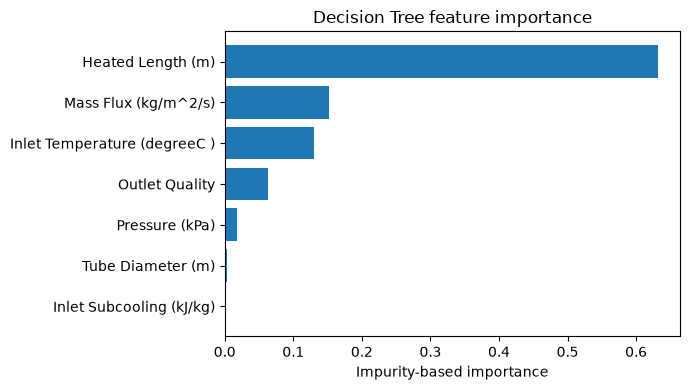

In [75]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Impurity importance": fitted_tree.feature_importances_,
}).sort_values("Impurity importance", ascending=False)

display(importance_df.style.format({"Impurity importance": "{:.3f}"}))

plt.figure(figsize=(7, 4))
plt.barh(importance_df["Feature"][::-1], importance_df["Impurity importance"][::-1])
plt.xlabel("Impurity-based importance")
plt.title("Decision Tree feature importance")
plt.tight_layout()
plt.show()

## 16. Parity and residual plots

Metrics compress performance into a single number; these two plots show *where* the model is right and wrong. We draw them on the **test** set.

**How to read them:**

- **Parity plot** (observed vs predicted): perfect predictions would land exactly on the diagonal line. Points **above** the line are under-predictions, points **below** are over-predictions. A tight cloud hugging the diagonal is good; a cloud that fans out at high CHF means larger errors for the largest targets.
- **Residual plot** (residual = observed − predicted, vs predicted): you want a **structureless band centred on zero**. Any pattern — a slope, a curve, or a funnel that widens — signals **systematic** error the model has not captured. For a tree specifically, watch for **vertical stripes**: because each leaf predicts a single constant, many samples share the exact same predicted value.


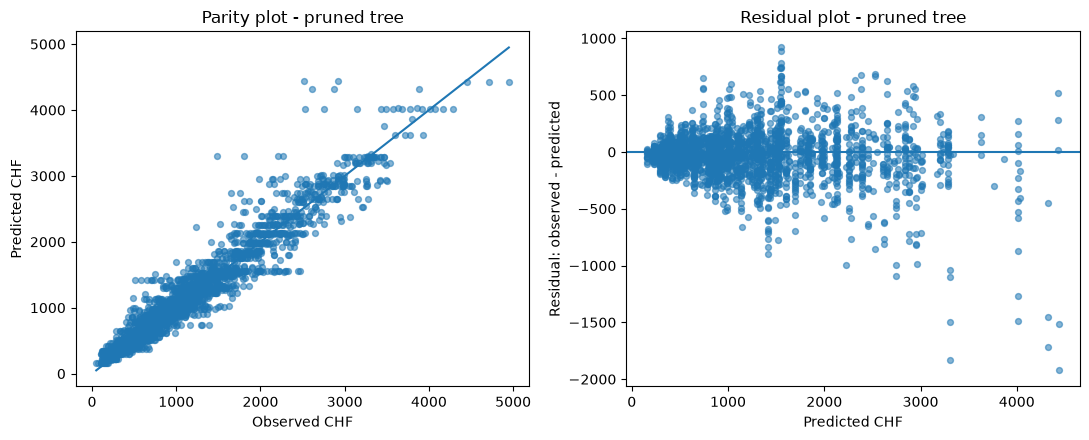

In [76]:
tree_test_pred = final_tree_predictions["Test"]

lims = [
    min(float(y_test.min()), float(np.min(tree_test_pred))),
    max(float(y_test.max()), float(np.max(tree_test_pred))),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test, tree_test_pred, alpha=0.55, s=18)
axes[0].plot(lims, lims)
axes[0].set_xlabel("Observed CHF")
axes[0].set_ylabel("Predicted CHF")
axes[0].set_title("Parity plot - pruned tree")

residuals = y_test - tree_test_pred
axes[1].scatter(tree_test_pred, residuals, alpha=0.55, s=18)
axes[1].axhline(0.0)
axes[1].set_xlabel("Predicted CHF")
axes[1].set_ylabel("Residual: observed - predicted")
axes[1].set_title("Residual plot - pruned tree")

plt.tight_layout()
plt.show()

## 17. Training-domain coverage check

Trees cannot extrapolate smoothly beyond the training feature range. This simple check flags validation/test rows that sit outside the train min-max range for at least one selected feature.

In [77]:
train_min = X_train.min()
train_max = X_train.max()

coverage_rows = []
for split_name, X in [("Validation", X_val), ("Test", X_test)]:
    outside = (X < train_min) | (X > train_max)
    coverage_rows.append({
        "Split": split_name,
        "Rows": len(X),
        "Rows outside train min-max on any feature": int(outside.any(axis=1).sum()),
        "Fraction outside": outside.any(axis=1).mean(),
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df.style.format({"Fraction outside": "{:.3f}"}))

,Split,Rows,Rows outside train min-max on any feature,Fraction outside
0,Validation,3150,41,0.013
1,Test,2307,1,0.000


## 17b. Out-of-domain (OOD) evaluation — where the tree breaks

The coverage check above only *counts* rows outside the training range. Now we actually **score** the models on three out-of-domain reference files that were never part of train/val/test. They are **not interchangeable** — each probes a different kind of failure:

- **`chf_OOD_Kim2000` — regime shift (clear).** Sits at much **lower pressure and mass flux** than training; many rows fall *below* the trained range, so the coverage fraction is high. This is the classic extrapolation case.
- **`chf_OOD_Peterlongo1966` — regime shift (subtle).** Larger mass flow at a larger pipe diameter (0.0151 m). Each of our three features is still *inside* the training min-max, so the coverage check reports ~0% outside — yet the *combination* is barely represented. **Min-max coverage is necessary, not sufficient.**
- **`chf_OOD_Lee1966` — source shift.** A different data source with a narrower operating window that stays within the trained ranges. Not extrapolation; a test of transfer to a new source.

This is the payoff of Section 10b's staircase picture. Watch for:

- **Trees flatten, they do not extrapolate.** Where Kim's features fall outside the trained range, the trees can only repeat their outermost leaf value, so error grows sharply. Ridge instead extends a straight-line trend — it fails *differently*, sometimes even worse.
- **A confident number is always returned.** Every model predicts happily on all three files. The `Fraction outside train min-max` column is your reminder that the coverage flag can stay silent (Lee, Peterlongo) even when the data are genuinely OOD.

> Part 2 (Tree Ensembles) reuses these same three files to stress-test the ensembles — so this is your single-tree reference for that comparison.

In [78]:
# Reuse the OOD files declared in Section 3. These rows come from references that
# are NOT in the training split, and often push into feature ranges the tree never
# saw. We compare the linear Ridge baseline against the pruned and unconstrained
# trees so the tree's inability to extrapolate becomes measurable, not just asserted.
ood_models = {
    "Ridge (linear)": ridge_model,
    "Pruned tree": final_tree,
    "Unconstrained tree": deep_tree,
}


def evaluate_ood_file(filename):
    path = data_dir / filename
    if not path.exists():
        print(f"Skipping missing file: {filename}")
        return None

    df = pd.read_csv(path)
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    outside = (X < train_min) | (X > train_max)

    rows = []
    for model_name, model in ood_models.items():
        pred = model.predict(X)
        row = regression_metrics(y, pred)
        row["File"] = filename
        row["Model"] = model_name
        row["Rows"] = len(df)
        row["Fraction outside train min-max"] = outside.any(axis=1).mean()
        rows.append(row)
    return pd.DataFrame(rows)


ood_tables = []
for filename in ood_files:
    result = evaluate_ood_file(filename)
    if result is not None:
        ood_tables.append(result)

if ood_tables:
    ood_results = pd.concat(ood_tables, ignore_index=True)
    ood_results = ood_results[[
        "File", "Model", "Rows", "Fraction outside train min-max", "MAE", "RMSE", "R2"
    ]]
    display(ood_results.style.format({
        "Fraction outside train min-max": "{:.3f}",
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R2": "{:.3f}",
    }))
else:
    print("No OOD files were found to evaluate.")

,File,Model,Rows,Fraction outside train min-max,MAE,RMSE,R2
0,chf_OOD_Kim2000.csv,Ridge (linear),482,0.797,1369.25,1403.66,-21.500
1,chf_OOD_Kim2000.csv,Pruned tree,482,0.797,609.20,696.86,-4.546
2,chf_OOD_Kim2000.csv,Unconstrained tree,482,0.797,596.46,687.65,-4.400
3,chf_OOD_Lee1966.csv,Ridge (linear),257,0.000,628.70,695.82,-0.484
4,chf_OOD_Lee1966.csv,Pruned tree,257,0.000,331.75,435.07,0.420
5,chf_OOD_Lee1966.csv,Unconstrained tree,257,0.000,334.65,415.62,0.470
6,chf_OOD_Peterlongo1966.csv,Ridge (linear),342,0.102,635.00,725.28,-1.261
7,chf_OOD_Peterlongo1966.csv,Pruned tree,342,0.102,430.91,504.89,-0.096
8,chf_OOD_Peterlongo1966.csv,Unconstrained tree,342,0.102,402.30,501.28,-0.080


## 18. Short interpretation questions

Please answer these briefly in markdown below:

1. Does the CV-selected pruned tree beat the Ridge baseline on validation and test RMSE?
2. Do the best CV parameters suggest a shallow, moderate, or very deep tree?
3. How different are the train, validation, and test errors for the unconstrained tree? What does this suggest?
4. Which feature appears most important in the final tree, and why should this be interpreted cautiously?
5. What warning does the training-domain coverage check give about using trees for extrapolation?
6. On the OOD files, how does the tree's error compare with Ridge, and how does that connect to the one-feature staircase in Section 10b?


In [79]:
# Write your brief interpretation here.
#
# 1. Baseline comparison:
# 2. CV-selected hyperparameters:
# 3. Overfitting evidence:
# 4. Useful split or feature:
# 5. Safe-use caution:


## 19. Final checklist

- You used the organiser-provided split.
- You compared Ridge, shallow tree, unconstrained tree, and a CV-selected pruned tree.
- You inspected the depth sweep.
- You tuned several tree hyperparameters with cross-validation on the training set.
- You visualised and interpreted the final tree carefully.
- You checked parity, residuals, feature importance, and training-domain coverage.
- You evaluated the models on the out-of-domain files and saw how a tree fails when asked to extrapolate.


In [80]:
print("Day 2 Lab 2 (Part 1) notebook completed successfully.")
print("You have trained, tuned, pruned, visualised, and interpreted a Decision Tree for CHF regression.")


Day 2 Lab 2 (Part 1) notebook completed successfully.
You have trained, tuned, pruned, visualised, and interpreted a Decision Tree for CHF regression.
